In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Final_Dataset.xlsx to Final_Dataset (1).xlsx


In [ ]:
# Load the cleaned dataset
df_cleaned = pd.read_excel('Final_Dataset.xlsx', sheet_name='Model_Dataset', skiprows=[0, 2])
df_cleaned.head()

,Date,BNB-USD,BTC-USD,ETH-USD,USDT-USD,XRP-USD,ADA-USD,BITG-USD,MIOTA-USD,XNO-USD,POWR-USD,Power,Ground Transport,Residential,Domestic Aviation,International Aviation
0,2019-01-03,-0.283723,-0.146478,-0.218059,-0.242175,-0.213296,-0.133797,0.272976,-0.350994,-0.212519,-0.541858,0.017161,0.100704,-0.013013,0.037922,0.026545
1,2019-01-04,0.250258,0.067790,0.155431,0.110796,0.026443,-0.276461,-0.199125,0.001564,0.155184,-0.798119,0.015954,0.002050,-0.008488,-0.013425,0.013110
2,2019-01-05,0.034520,0.058029,0.065619,0.024849,0.003227,0.448817,-1.063302,-0.364719,0.394051,0.533827,-0.031367,-0.072048,-0.042761,-0.084376,0.028308
3,2019-01-06,0.314991,0.085648,-0.032553,0.056192,0.085732,0.716078,-0.655398,0.427898,0.268170,1.404755,-0.020110,-0.145075,-0.015340,0.001235,0.016680
4,2019-01-07,-0.092145,-0.068087,-0.175156,-0.115993,0.013049,-0.117139,0.675955,-0.436056,-0.465483,-1.400369,0.045889,0.199612,0.012749,0.042424,-0.069635


In [ ]:
df_cleaned.isna()

,Date,BNB-USD,BTC-USD,ETH-USD,USDT-USD,XRP-USD,ADA-USD,BITG-USD,MIOTA-USD,XNO-USD,POWR-USD,Power,Ground Transport,Residential,Domestic Aviation,International Aviation
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1545,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1546,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1547,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_cleaned.isna().sum()

,0
Date,0
BNB-USD,0
BTC-USD,0
ETH-USD,0
USDT-USD,0
XRP-USD,0
ADA-USD,0
BITG-USD,34
MIOTA-USD,0
XNO-USD,5


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Select only the required columns
df_cleaned1 = df_cleaned[['Date', 'ADA-USD', 'BITG-USD','MIOTA-USD', 'XNO-USD', 'POWR-USD',	'Power']]

# Check the first few rows of the modified DataFrame
df_cleaned1.head()
df_cleaned1.dropna(inplace=True)
df_cleaned1.isnull().sum()
df_cleaned1.shape


(1510, 7)

In [ ]:
warnings.filterwarnings('ignore')

# Create lagged features for Power
df_cleaned1['Power_lag_1'] = df_cleaned1['Power'].shift(1)
df_cleaned1['Power_lag_2'] = df_cleaned1['Power'].shift(2)

# Be sure to drop NaNs created by lagging
df_cleaned1.dropna(inplace=True)

# Select input features and the output variable
input_features = ['ADA-USD', 'BITG-USD', 'MIOTA-USD', 'XNO-USD', 'POWR-USD', 'Power_lag_1', 'Power_lag_2']
output_feature = 'Power'

In [ ]:
# Prepare the input (exogenous) and output (target) variables
exog_variables = df_cleaned1[input_features].values
output_variable = df_cleaned1[output_feature].values

# Scale the features and the target variable using MinMaxScaler
scaler_exog = MinMaxScaler()
scaler_target = MinMaxScaler()

scaled_exog_variables = scaler_exog.fit_transform(exog_variables)
scaled_output_variable = scaler_target.fit_transform(output_variable.reshape(-1, 1))

print("Min/Max scaled features:", np.nanmin(scaled_exog_variables), np.nanmax(scaled_exog_variables))
print("Min/Max scaled target:", np.nanmin(scaled_output_variable), np.nanmax(scaled_output_variable))

print("Target variable statistics before scaling:")
print(df_cleaned1['Power'].describe())

Min/Max scaled features: 0.0 1.0
Min/Max scaled target: 0.0 1.0
Target variable statistics before scaling:
count    1508.000000
mean       -0.000065
std         0.033133
min        -0.131578
25%        -0.022977
50%        -0.002607
75%         0.017423
max         0.113131
Name: Power, dtype: float64


In [ ]:
print("Feature variance:")
print(df_cleaned1[input_features].var())


Feature variance:
ADA-USD        0.106841
BITG-USD       0.716050
MIOTA-USD      0.165506
XNO-USD        0.252601
POWR-USD       1.050009
Power_lag_1    0.001098
Power_lag_2    0.001098
dtype: float64


In [ ]:
# Define the number of timesteps (e.g., how many previous days to use)
time_steps = 5

In [ ]:
# Create LSTM-compatible data (samples, timesteps, features)
def create_lstm_data(exog_data, target_data, time_steps):
    X, y = [], []
    for i in range(time_steps, len(exog_data)):
        X.append(exog_data[i-time_steps:i, :])
        y.append(target_data[i])
    return np.array(X), np.array(y)

In [ ]:
# Create the LSTM-compatible data
X, y = create_lstm_data(scaled_exog_variables, scaled_output_variable, time_steps)

In [ ]:
# Split the data into training and testing sets (85% training, 15% testing)
train_size = int(len(X) * 0.85)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training data shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing data shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training data shape: X_train: (1277, 5, 7), y_train: (1277, 1)
Testing data shape: X_test: (226, 5, 7), y_test: (226, 1)


In [ ]:
# Build the LSTM model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

warnings.filterwarnings('ignore')

# Adjust the model with more LSTM units and layers
model = Sequential()
model.add(LSTM(units=350, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(LSTM(units=300, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=250, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=150, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1))



In [ ]:
from tensorflow.keras.optimizers import Adam

# Use a lower learning rate
model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
# Train the model for more epochs
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test), verbose=2)


Epoch 1/40
40/40 - 15s - 363ms/step - loss: 0.0533 - val_loss: 0.0151
Epoch 2/40
40/40 - 6s - 139ms/step - loss: 0.0180 - val_loss: 0.0125
Epoch 3/40
40/40 - 9s - 237ms/step - loss: 0.0108 - val_loss: 0.0097
Epoch 4/40
40/40 - 7s - 165ms/step - loss: 0.0100 - val_loss: 0.0111
Epoch 5/40
40/40 - 8s - 207ms/step - loss: 0.0101 - val_loss: 0.0090
Epoch 6/40
40/40 - 7s - 174ms/step - loss: 0.0092 - val_loss: 0.0079
Epoch 7/40
40/40 - 8s - 211ms/step - loss: 0.0081 - val_loss: 0.0084
Epoch 8/40
40/40 - 6s - 159ms/step - loss: 0.0088 - val_loss: 0.0078
Epoch 9/40
40/40 - 9s - 225ms/step - loss: 0.0084 - val_loss: 0.0076
Epoch 10/40
40/40 - 10s - 248ms/step - loss: 0.0084 - val_loss: 0.0074
Epoch 11/40
40/40 - 7s - 166ms/step - loss: 0.0084 - val_loss: 0.0077
Epoch 12/40
40/40 - 5s - 115ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 13/40
40/40 - 5s - 123ms/step - loss: 0.0079 - val_loss: 0.0076
Epoch 14/40
40/40 - 6s - 155ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 15/40
40/40 - 10s - 2

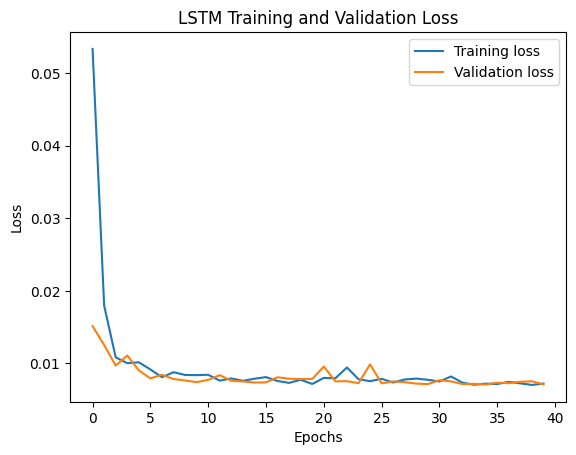

In [ ]:
# Plot the training and validation loss
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the predictions and the actual values to get them back to their original scale
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


In [ ]:
# Calculate performance metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

mean_actual = np.mean(y_test_actual)
rrse = np.sqrt(np.sum((y_pred - y_test_actual) ** 2) / np.sum((y_test_actual - mean_actual) ** 2))


In [ ]:
# Print the performance metrics
print("LSTM Model Validation Metrics:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")
print(f"R-Squared (R²): {r2}")
print(f"Root Relative Squared Error (RRSE): {rrse}")

LSTM Model Validation Metrics:
Mean Squared Error (MSE): 0.0004256453202327219
Mean Absolute Error (MAE): 0.014684035122891764
Root Mean Squared Error (RMSE): 0.020631173505952633
Mean Absolute Percentage Error (MAPE): 1.0295570791526796
R-Squared (R²): 0.5236072360860555
Root Relative Squared Error (RRSE): 0.6902121151602197


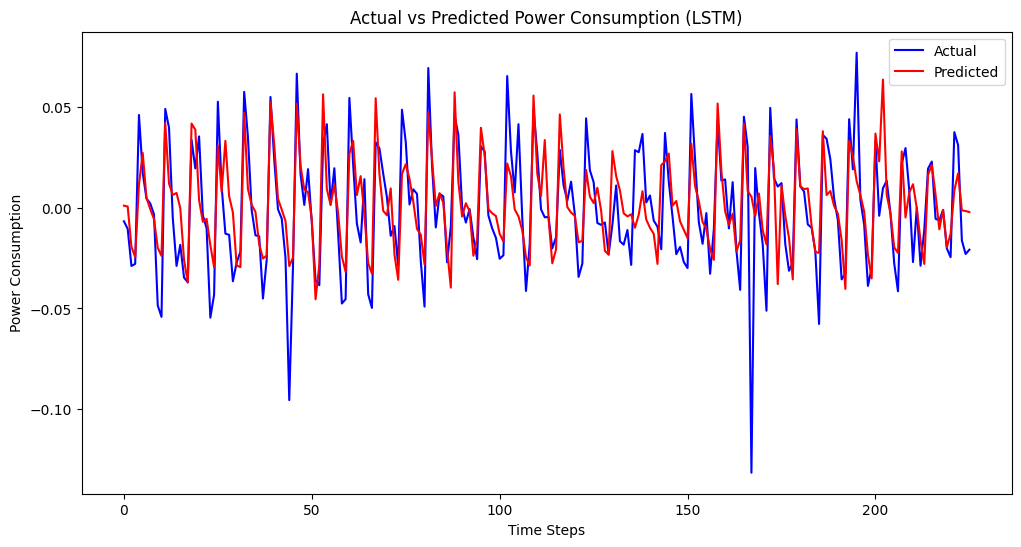

In [ ]:
# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Power Consumption (LSTM)')
plt.xlabel('Time Steps')
plt.ylabel('Power Consumption')
plt.legend()
plt.show()


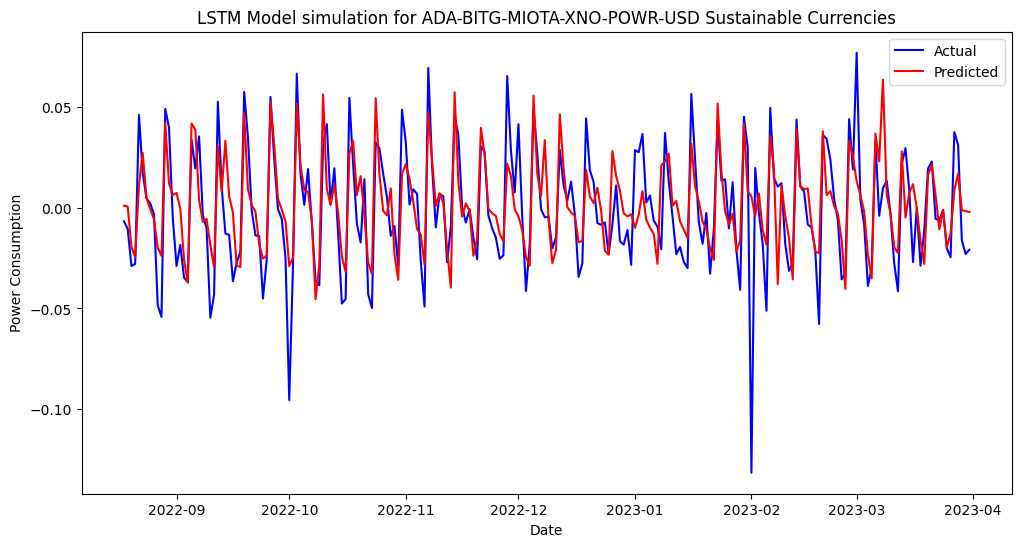

In [ ]:
# Plot the actual vs predicted values using Date for the x-axis
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned1['Date'][train_size + time_steps:], y_test_actual.flatten(), label='Actual', color='blue')
plt.plot(df_cleaned1['Date'][train_size + time_steps:], y_pred.flatten(), label='Predicted', color='red')
plt.title('LSTM Model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies')
plt.xlabel('Date')
plt.ylabel('Power Consumption')
plt.legend()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Step 1: Combine the actual and predicted values into a single DataFrame
df_results = pd.DataFrame({
    'Date': df_cleaned['Date'][1282:1508],
    'Actual': y_test_actual.flatten(),
    'Predicted': y_pred.flatten()
})

# Step 2: Create the line plot with Plotly Express
fig = px.line(df_results,
              x='Date',
              y=['Actual', 'Predicted'],
              labels={'value': 'Power Consumption', 'variable': 'Legend'},
              title="LSTM Model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies")

# Step 3: Show the plot
fig.show()


In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Create a DataFrame with Actual and Predicted values
df_results = pd.DataFrame({
    'Date': df_cleaned['Date'][1282:1508],
    'Actual': y_test_actual.flatten(),
    'Predicted': y_pred.flatten()
})

# Initialize a figure
fig = go.Figure()

# Add trace for Actual values (Expectation)
fig.add_trace(go.Scatter(
    x=df_results['Date'],
    y=df_results['Actual'],
    name="Actual",
    mode="lines",
    line=dict(color='blue')
))

# Add trace for Predicted values (Prediction)
fig.add_trace(go.Scatter(
    x=df_results['Date'],
    y=df_results['Predicted'],
    name="Predicted",
    mode="lines",
    line=dict(color='green')
))

# Customize layout
fig.update_layout(
    title="LSTM Model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies",
    xaxis=dict(title="Date"),
    yaxis=dict(title="Power Consumption"),
    hovermode="x unified",
)

# Add data points on hover
fig.update_traces(hovertemplate="Date: %{x}<br>Value: %{y}")

# Add range slider for Date
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

# Show the plot
fig.show()
